### Dream Housing Finance company deals in all home loans. They have presence across all urban, semi urban and rural areas. Customer first apply for home loan after that company validates the customer eligibility for loan.

### The company wants to automate the loan eligibility process (real time) based on customer detail provided while filling online application form. These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. To automate this process, they have given a problem to identify the customers segments, those are eligible for loan amount so that they can specifically target these customers. Here they have provided a partial data set.

From the above problem statement - Need to automate the Loan approval process based on the attributes provided. 
Which means, need to find the attributes, which helps in filitering the customer eligible for loan amount.

In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [9]:
data = pd.read_csv('train.csv')
data.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


There are 12 attributes in the data. 
Among them, 5 attributes are numerical & 8 attributes are categorical

________________________________________________________________________________________________________________________

# EDA: Exploratory data Analysis

The Target variable here is Loan Status.       
Type of the Target variable is Categorical. 

In [11]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Among these attributes, Gender, Married could be ignored. Since, these doesn't affect the customer eligibility to get a home loan. 

However, with null values in Customer details with Self-Employed, Loan amount, Loan amount term, and Credit history would be difficult to understand the data.

In order to fill the null values, we should understand the attribute distribution. Generally, the missing values could be filled with Mean, Mode, Media or any value based on our observation using Simple Imputer class from Sklearn

In [12]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### Applicant Income:

Missing Values: 0      
Mean & Median Varies a little. Mean value is near by to 75%, which means the data is skewed a little.

In [23]:
# Dividing the data baded on the type

data_num=data.select_dtypes('number')
data_cat=data.select_dtypes('object').drop('Loan_ID', axis=1)


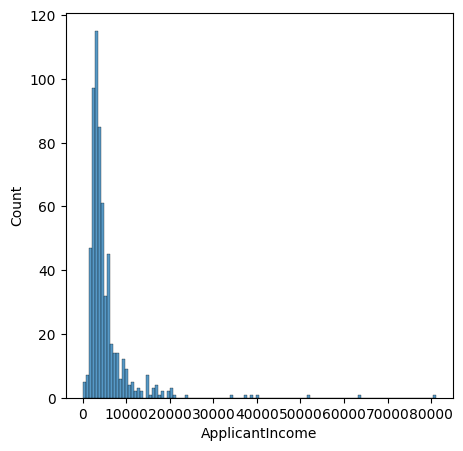

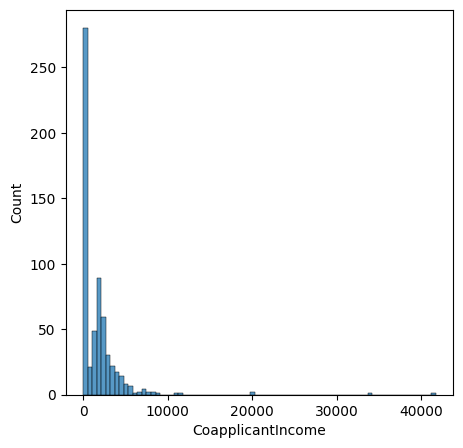

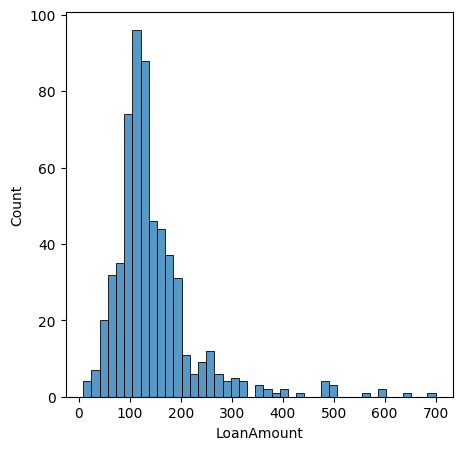

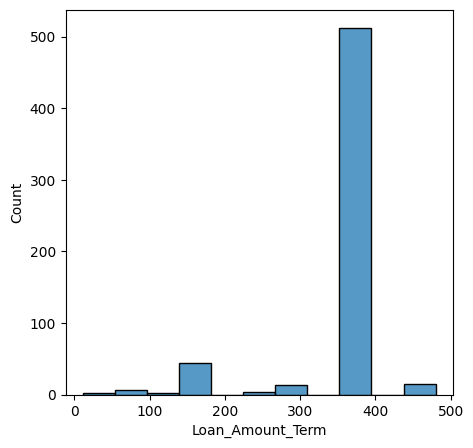

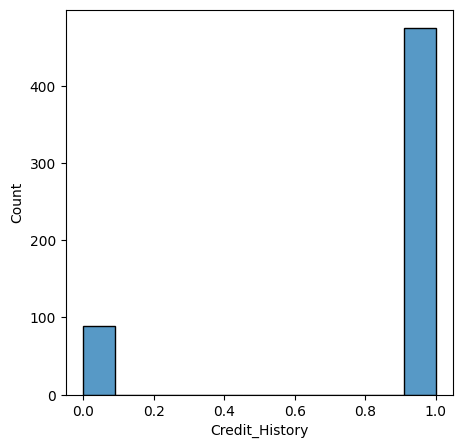

In [25]:
for att in data_num:
    plt.figure(figsize=(5,5))
    sns.histplot(data, x=att)
    plt.show()



Categorical attrbutes null values could be filled with Mode or could also drop the null values. I want proceed and fill them with Mode instead of dropping them. 

### Let's visualize how data is dependent on Target variable.

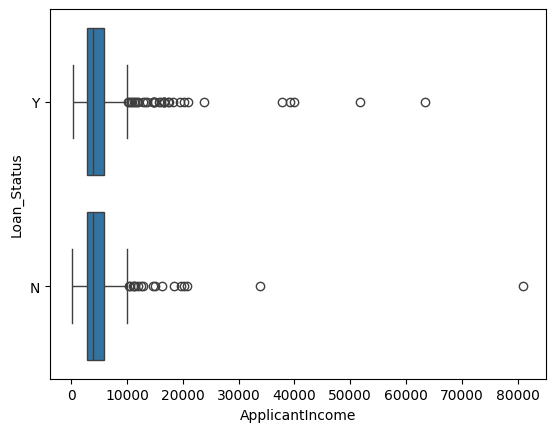

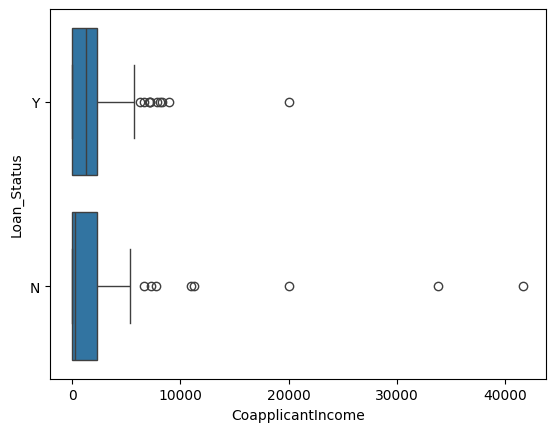

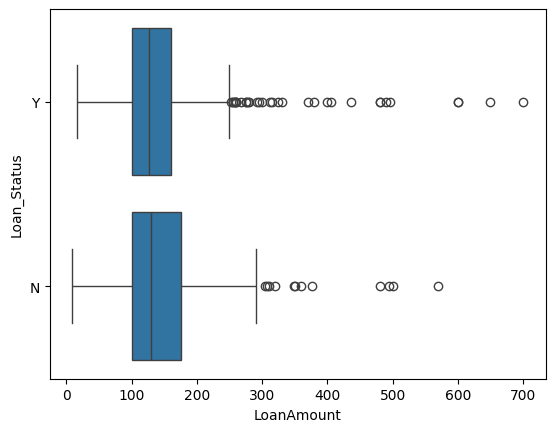

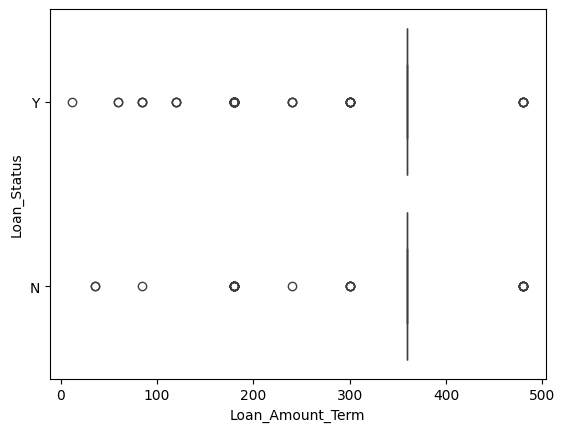

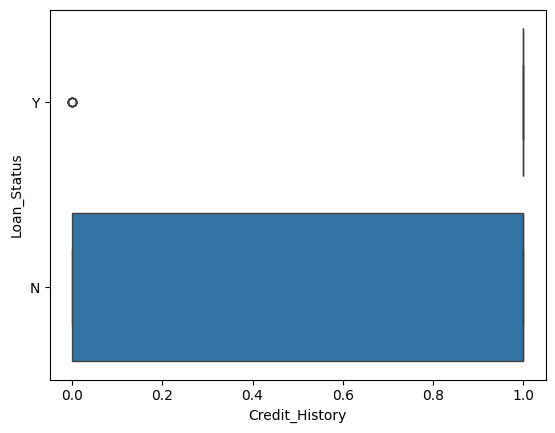

In [6]:
# Visualizing Numerical attribute with respect to Target attribute
import seaborn as sns


for feature in data_num:
    sns.boxplot(data, x=feature, y='Loan_Status' )
    plt.show()

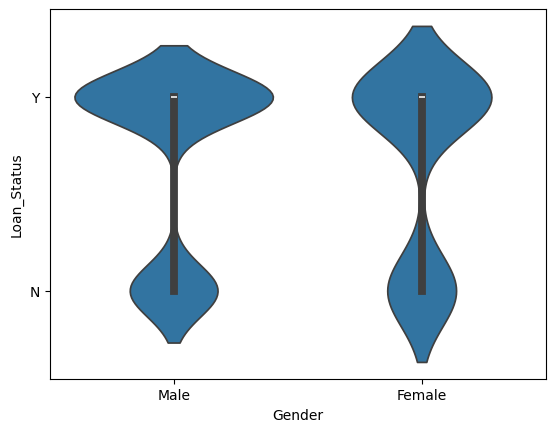

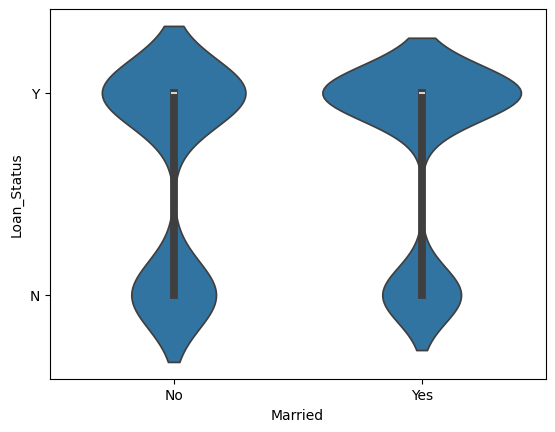

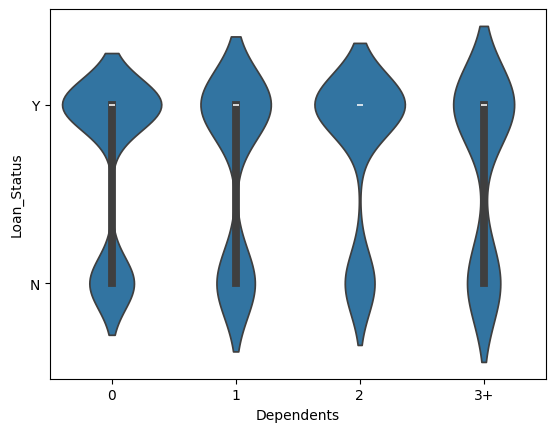

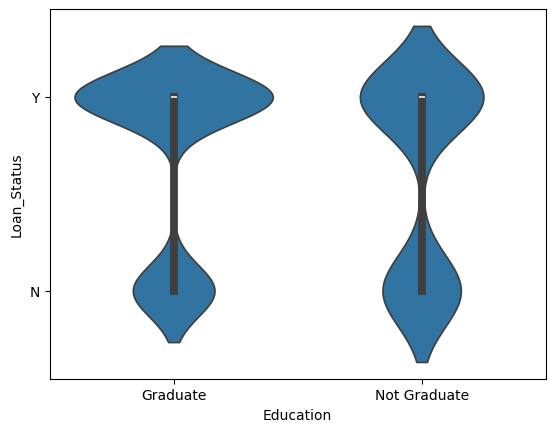

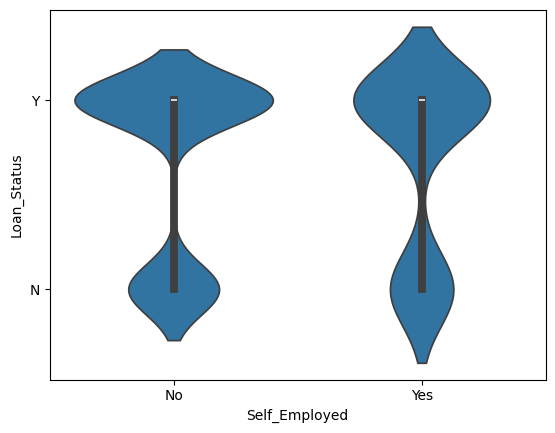

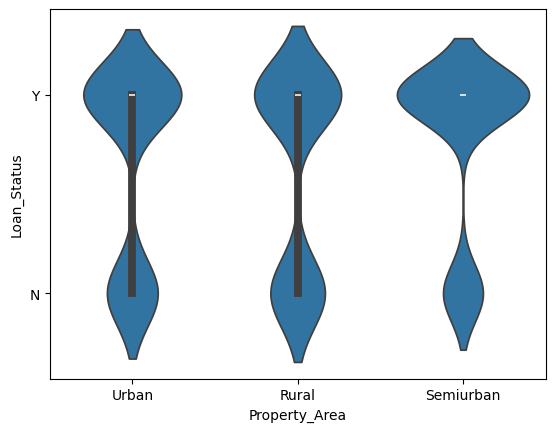

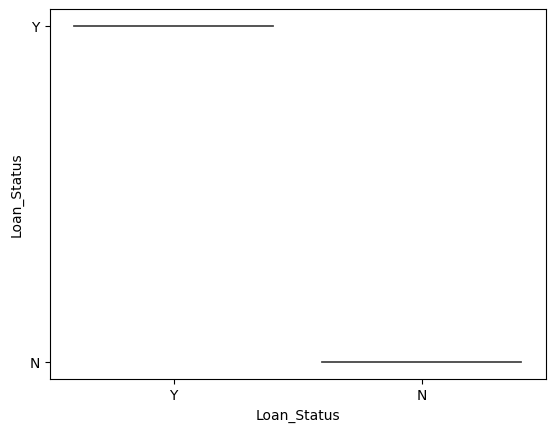

In [8]:
# Visualizing Categorical Attribute with respect to Target attribute

for attribut in data_cat:
    sns.violinplot(data, x=attribut, y='Loan_Status')
    plt.show()

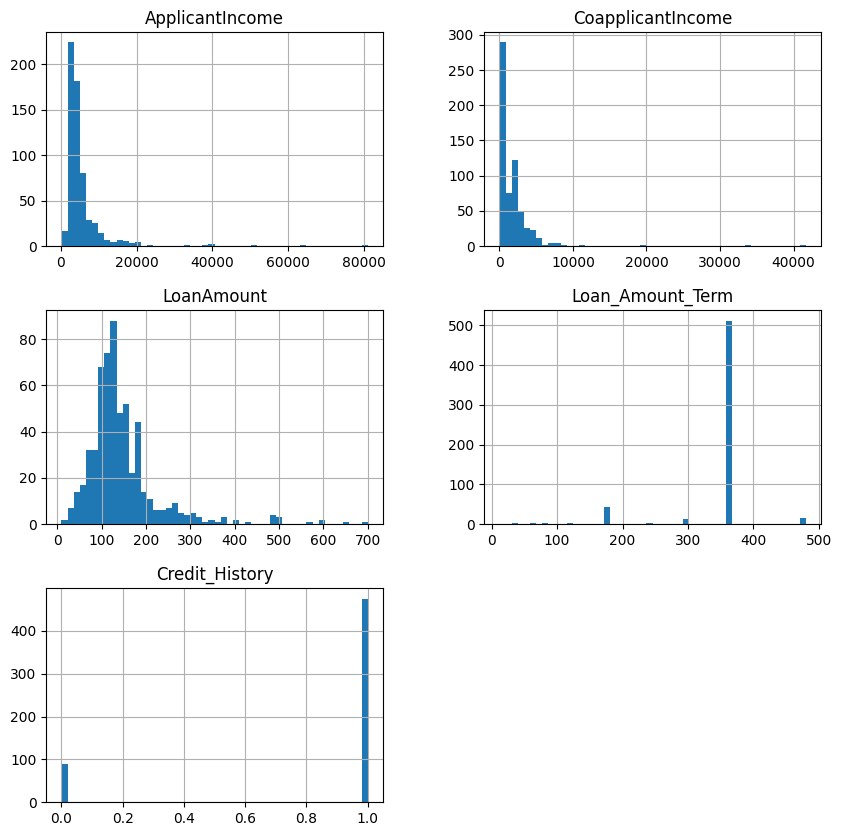

In [9]:
# visualizing Numerical feature distribution

data.hist(bins=50, figsize=(10,10))
plt.show()

________________________________________________

# Feature Engineering

###  Filling the Missing Data Values by using Mean - Numerical Attributes & Mode - Categorical Atributes

In [10]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Cat_attributes=['Gender', 'Married', 'Dependents', 'Self_Employed']
Num_attributes=['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

data['Gender'].mode()

# Filling the categorical values 

for x in Cat_attributes:
    mode_values=data[x].mode()[0]
    data[x]=data[x].fillna(mode_values)


data['LoanAmount'].mean()


# Filling the Numerical values

for y in Num_attributes:
    mean_values=data[y].mean()
    data[y]=data[y].fillna(mean_values)


All the missing values were replaced and the extra attributes were combined and craeted a new attribute. The data is clean and good for further process in Machine Learning

___________

# Let's fill the values of the features using Imputer

In [11]:
data_cat.value_counts().sort_values()

Gender  Married  Dependents  Education     Self_Employed  Property_Area  Loan_Status
Male    Yes      3+          Not Graduate  Yes            Urban          Y               1
Female  No       1           Not Graduate  No             Rural          N               1
                                           Yes            Semiurban      N               1
                 2           Graduate      No             Urban          N               1
                 3+          Graduate      No             Rural          Y               1
                                                                                        ..
Male    Yes      2           Graduate      No             Urban          Y              16
                                                          Semiurban      Y              18
                 0           Graduate      No             Rural          Y              23
                                                          Urban          Y              24
     

All the values in Categorical features are in Ordinal format

### Filling Numerical features

In [12]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='mean')
imputer.fit(data_num)
transformed_data=imputer.transform(data_num)

The transformed data is saved in array form.

Convert the array to Data frame

In [13]:
num_data=pd.DataFrame(transformed_data, columns=data_num.columns, index=data_num.index)
num_data.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849.0,0.0,146.412162,360.0,1.0
1,4583.0,1508.0,128.000000,360.0,1.0
2,3000.0,0.0,66.000000,360.0,1.0
3,2583.0,2358.0,120.000000,360.0,1.0
4,6000.0,0.0,141.000000,360.0,1.0


In [14]:
# Numerical attributes data with 0 null values

num_data.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
dtype: int64

### Filling Categorical Feature

In [15]:
from sklearn.impute import SimpleImputer
impute_mode=SimpleImputer(strategy='most_frequent')
transformedcat_data=impute_mode.fit_transform(data_cat)

In [16]:
# Categorical attributes data with 0 null values


cat_data = pd.DataFrame(transformedcat_data, columns=data_cat.columns)
cat_data.isnull().sum()

Gender           0
Married          0
Dependents       0
Education        0
Self_Employed    0
Property_Area    0
Loan_Status      0
dtype: int64

In [17]:
dataset=pd.concat([num_data, cat_data], axis=1)
dataset.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,5849.0,0.0,146.412162,360.0,1.0,Male,No,0,Graduate,No,Urban,Y
1,4583.0,1508.0,128.000000,360.0,1.0,Male,Yes,1,Graduate,No,Rural,N
2,3000.0,0.0,66.000000,360.0,1.0,Male,Yes,0,Graduate,Yes,Urban,Y
3,2583.0,2358.0,120.000000,360.0,1.0,Male,Yes,0,Not Graduate,No,Urban,Y
4,6000.0,0.0,141.000000,360.0,1.0,Male,No,0,Graduate,No,Urban,Y


In [18]:
dataset.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
Property_Area        0
Loan_Status          0
dtype: int64

The data is filled with mean and mode values. Let's check for the attribute distribution

# Converting Categorical to Numerical

To convert the Categorical Features to Numerical Features: 
1. One Hot Encoder
2. Oridinal Encoder
3. Label Encoder
4. Target Encoder

In [19]:
num_data.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849.0,0.0,146.412162,360.0,1.0
1,4583.0,1508.0,128.000000,360.0,1.0
2,3000.0,0.0,66.000000,360.0,1.0
3,2583.0,2358.0,120.000000,360.0,1.0
4,6000.0,0.0,141.000000,360.0,1.0


In [20]:
cat_data.head()

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,Urban,Y
1,Male,Yes,1,Graduate,No,Rural,N
2,Male,Yes,0,Graduate,Yes,Urban,Y
3,Male,Yes,0,Not Graduate,No,Urban,Y
4,Male,No,0,Graduate,No,Urban,Y


In [21]:
## OneHot Encoder

#data_cat=dataset.select_dtypes('object')
#data_num1=dataset.select_dtypes('number')

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

#applying oridinal encoder

oe=OrdinalEncoder()
cat_encode=oe.fit_transform(cat_data)



In [22]:
#saving the transformed data
cat_encode

array([[1., 0., 0., ..., 0., 2., 1.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 0., ..., 1., 2., 1.],
       ...,
       [1., 1., 1., ..., 0., 2., 1.],
       [1., 1., 2., ..., 0., 2., 1.],
       [0., 0., 0., ..., 1., 1., 0.]])

In [23]:
# the transfomed data will be in the form of array. Convert the array to Dataframe with the columns heading.

df_cat_encode=pd.DataFrame(cat_encode, columns=cat_data.columns)
df_cat_encode.head()

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,1.0,0.0,0.0,0.0,0.0,2.0,1.0
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,1.0,2.0,1.0
3,1.0,1.0,0.0,1.0,0.0,2.0,1.0
4,1.0,0.0,0.0,0.0,0.0,2.0,1.0


In [24]:
# Concatinating the encoded categorical atteibutes with numerical attributes

dataset=pd.concat([df_cat_encode, num_data], axis=1)
dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,5849.0,0.0,146.412162,360.0,1.0
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4583.0,1508.0,128.000000,360.0,1.0
2,1.0,1.0,0.0,0.0,1.0,2.0,1.0,3000.0,0.0,66.000000,360.0,1.0
3,1.0,1.0,0.0,1.0,0.0,2.0,1.0,2583.0,2358.0,120.000000,360.0,1.0
4,1.0,0.0,0.0,0.0,0.0,2.0,1.0,6000.0,0.0,141.000000,360.0,1.0


_______________________

### Checking for Numerical attributes distribution

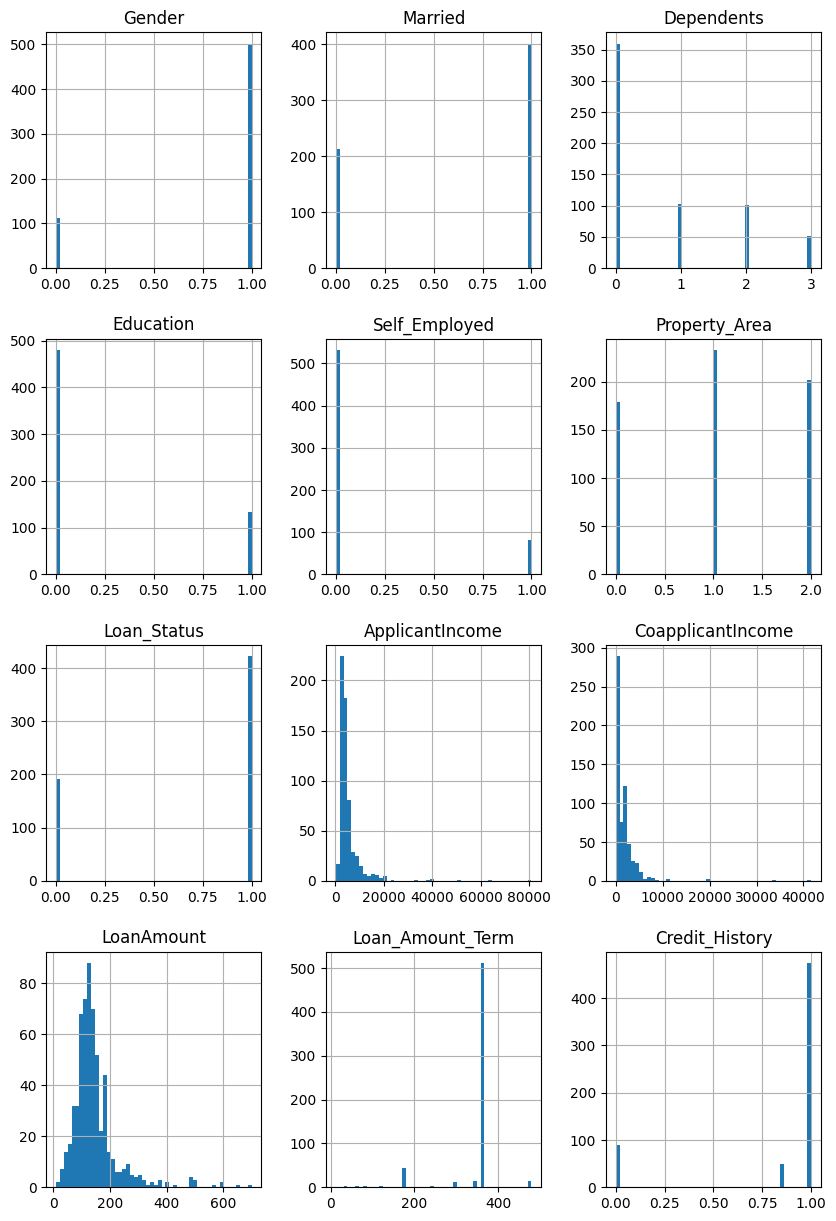

In [25]:

dataset.hist(bins=50, figsize=(10,15))
plt.show()

# Feature Scaling

Converting the data to Normal distribution

In [26]:
dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,5849.0,0.0,146.412162,360.0,1.0
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4583.0,1508.0,128.000000,360.0,1.0
2,1.0,1.0,0.0,0.0,1.0,2.0,1.0,3000.0,0.0,66.000000,360.0,1.0
3,1.0,1.0,0.0,1.0,0.0,2.0,1.0,2583.0,2358.0,120.000000,360.0,1.0
4,1.0,0.0,0.0,0.0,0.0,2.0,1.0,6000.0,0.0,141.000000,360.0,1.0


In [27]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# excluding target attribute while performing Feature scaling
feature_scale=dataset.drop('Loan_Status', axis=1)
target=dataset['Loan_Status']

#fit & transform the Stansard scaler
ss=StandardScaler()
ss_data=ss.fit_transform(feature_scale)

In [28]:
#Converting the scaled array to dataframe

ss_data=pd.DataFrame(ss_data, columns=feature_scale.columns)
ss_data.head()

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,1.223298,0.072991,-0.554487,0.000000,0.279851,0.45164
1,0.472343,0.728816,0.253470,-0.528362,-0.392601,-1.318513,-0.134412,-0.038732,-0.219273,0.279851,0.45164
2,0.472343,0.728816,-0.737806,-0.528362,2.547117,1.223298,-0.393747,-0.554487,-0.957641,0.279851,0.45164
3,0.472343,0.728816,-0.737806,1.892641,-0.392601,1.223298,-0.462062,0.251980,-0.314547,0.279851,0.45164
4,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,1.223298,0.097728,-0.554487,-0.064454,0.279851,0.45164


In [29]:
dataset=pd.concat([ss_data, target], axis=1)
dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,1.223298,0.072991,-0.554487,0.000000,0.279851,0.45164,1.0
1,0.472343,0.728816,0.253470,-0.528362,-0.392601,-1.318513,-0.134412,-0.038732,-0.219273,0.279851,0.45164,0.0
2,0.472343,0.728816,-0.737806,-0.528362,2.547117,1.223298,-0.393747,-0.554487,-0.957641,0.279851,0.45164,1.0
3,0.472343,0.728816,-0.737806,1.892641,-0.392601,1.223298,-0.462062,0.251980,-0.314547,0.279851,0.45164,1.0
4,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,1.223298,0.097728,-0.554487,-0.064454,0.279851,0.45164,1.0


# Feature Selection

Since, the data I am using is already slit into test & train data. However, I had trained train data and haven't called test data. Let's split the data to Test & Train data set, when already the split data is avilable.

Now, Split the train data set to Attribute vs Target attribute.

Here, the data goal is to find the attributes which assist in filtering the customers eligible for House Loan. If we consider all the attributes in Train data set, the last attribute "Loan_Status" would be the Traget Attrubute. As this attribute provide the data of the customer eligible for House loan. 


In [30]:
# Splitting Train data set to x & y : y=Traget attribute

y=dataset['Loan_Status']
X=dataset.drop('Loan_Status', axis=1)


In [31]:
y.head(5)

0    1.0
1    0.0
2    1.0
3    1.0
4    1.0
Name: Loan_Status, dtype: float64

In [32]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,1.223298,0.072991,-0.554487,0.000000,0.279851,0.45164
1,0.472343,0.728816,0.253470,-0.528362,-0.392601,-1.318513,-0.134412,-0.038732,-0.219273,0.279851,0.45164
2,0.472343,0.728816,-0.737806,-0.528362,2.547117,1.223298,-0.393747,-0.554487,-0.957641,0.279851,0.45164
3,0.472343,0.728816,-0.737806,1.892641,-0.392601,1.223298,-0.462062,0.251980,-0.314547,0.279851,0.45164
4,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,1.223298,0.097728,-0.554487,-0.064454,0.279851,0.45164


### ANOVA - Feature selection

In [33]:
from sklearn.feature_selection import f_classif, SelectKBest

# Select top k features using ANOVA F-value
selector = SelectKBest(f_classif, k=5)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("Selected Features (ANOVA):", selected_features)


Selected Features (ANOVA): Index(['Married', 'Education', 'CoapplicantIncome', 'LoanAmount',
       'Credit_History'],
      dtype='object')


### Correlation - Feature selection

In [34]:

# Calculate correlation matrix
correlation_matrix = dataset.corr()

# Select features with high correlation with the target variable
target_correlation = correlation_matrix['Loan_Status'].abs()
selected_features = target_correlation[target_correlation > 0.1].index
print("Selected Features (Correlation):", selected_features)


Selected Features (Correlation): Index(['Credit_History', 'Loan_Status'], dtype='object')


## Embeded Method

### Lasso method - Feature selection

In [35]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

# Initialize Lasso model
lasso = Lasso(alpha=0.01)

# Fit model
lasso.fit(X, y)

# Select features
model = SelectFromModel(lasso, prefit=True)
X_lasso = model.transform(X)

# Get selected feature names
selected_features_lasso = X.columns[model.get_support()]
print("Selected Features (Lasso):", selected_features_lasso)



Selected Features (Lasso): Index(['Married', 'Education', 'Property_Area', 'CoapplicantIncome',
       'LoanAmount', 'Credit_History'],
      dtype='object')


c:\Users\ntabjul\Downloads\ML Projects\.venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [36]:
# among these 3 feature selection methods. the best features are:

selected_features = ['Married', 'Education', 'CoapplicantIncome', 'LoanAmount', 'Credit_History']

In [37]:

X=X[selected_features]

X.head()

,Married,Education,CoapplicantIncome,LoanAmount,Credit_History
0,-1.372089,-0.528362,-0.554487,0.000000,0.45164
1,0.728816,-0.528362,-0.038732,-0.219273,0.45164
2,0.728816,-0.528362,-0.554487,-0.957641,0.45164
3,0.728816,1.892641,0.251980,-0.314547,0.45164
4,-1.372089,-0.528362,-0.554487,-0.064454,0.45164


## Split Data to Train & Test

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20, test_size=0.2)

In [39]:
X_train.shape, X_test.shape

((491, 5), (123, 5))

# ML Model Training

The ML Models trying to apply to data to get the best ML model

1. Logistic
2. Random Forest
3. SVM
4. KNN
5. Decision tree

## Logistic regression

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

logis_X = X.copy()
logis_y = y.copy()


### applying Train & test split for Logistic regression


In [41]:
logisX_train, logisX_test, logisy_train, logisy_test = train_test_split(logis_X, logis_y, random_state=20, test_size=0.2)


In [42]:
LR = LogisticRegression()

# Define the parameter grid
LRparam_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}


In [43]:
# Initialize GridSearchCV
LRgrid_search = GridSearchCV(estimator=LR, param_grid=LRparam_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
LRgrid_search.fit(logisX_train, logisy_train)


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [45]:
# Make predictions
LRy_pred = LRgrid_search.predict(logisX_test)

# Evaluate performance
LRaccuracy = accuracy_score(logisy_test, LRy_pred)
precision = precision_score(logisy_test, LRy_pred, average='binary')
recall = recall_score(logisy_test, LRy_pred, average='binary')
f1 = f1_score(logisy_test, LRy_pred, average='binary')
roc_auc = roc_auc_score(logisy_test, LRy_pred)

print(f'Best Parameters: {LRgrid_search.best_params_}')
print(f'Accuracy: {LRaccuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-Score: {f1:.2f}')
print(f'ROC-AUC: {roc_auc:.2f}')

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy: 0.74
Precision: 0.70
Recall: 0.99
F1-Score: 0.82
ROC-AUC: 0.69


## Randomforest Classifier

In [46]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model = RandomForestClassifier(random_state=42)


In [47]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}


In [48]:
from sklearn.model_selection import GridSearchCV

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)


c:\Users\ntabjul\Downloads\ML Projects\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
241 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ntabjul\Downloads\ML Projects\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ntabjul\Downloads\ML Projects\.venv\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\ntabjul\Downloads\ML Projects\.venv\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
   

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Best Cross-Validation Score: 0.8248814677386106


In [49]:
from sklearn.metrics import accuracy_score, classification_report

# Train the model with the best parameters
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy on Test Set: 0.7398373983739838
Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.39      0.56        51
         1.0       0.70      0.99      0.82        72

    accuracy                           0.74       123
   macro avg       0.82      0.69      0.69       123
weighted avg       0.80      0.74      0.71       123



In [50]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=100, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = random_search.best_params_
best_score = random_search.best_score_
print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

# Train the model with the best parameters
best_model = random_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Best Cross-Validation Score: 0.824860853432282
Accuracy on Test Set: 0.7398373983739838
Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.39      0.56        51
         1.0       0.70      0.99      0.82        72

    accuracy                           0.74       123
   macro avg       0.82      0.69      0.69       123
weighted avg       0.80      0.74      0.71       123



c:\Users\ntabjul\Downloads\ML Projects\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
200 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
125 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ntabjul\Downloads\ML Projects\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ntabjul\Downloads\ML Projects\.venv\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\ntabjul\Downloads\ML Projects\.venv\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    

# model validation

In [51]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean Cross-Validation Score:", cv_scores.mean())


Cross-Validation Scores: [0.81818182 0.80612245 0.8877551  0.83673469 0.7755102 ]
Mean Cross-Validation Score: 0.824860853432282


Random Classifier is the good fit to the model compared to Logistic Regression

# Model interpretation

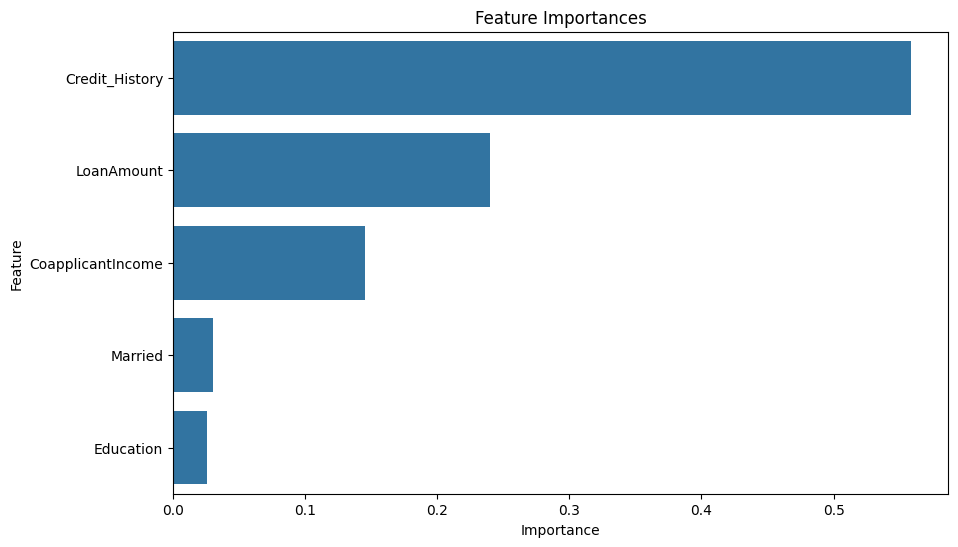

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
feature_importances = best_model.feature_importances_
features = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances')
plt.show()


# Model testing

Accuracy on Test Set: 0.7398373983739838
Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.39      0.56        51
         1.0       0.70      0.99      0.82        72

    accuracy                           0.74       123
   macro avg       0.82      0.69      0.69       123
weighted avg       0.80      0.74      0.71       123



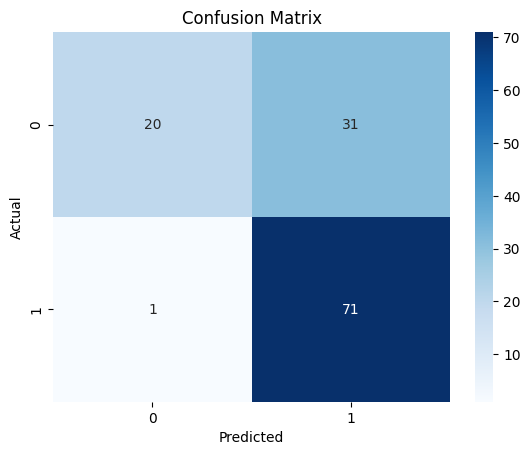

In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# model deployment

In [54]:
import joblib

# Save the model
joblib.dump(best_model, 'loan_prediction_model.pkl')


['loan_prediction_model.pkl']

In [55]:
# saving the dataset

import os

X_train.to_csv('data/X_train.csv', index=False)
y.to_csv('data/target.csv', index=False)